# Capstone 2 - Starbucks Report Analysis

##  Initial Setup

#### Install Required Libraries


In [1]:
!pip install openai langchain langchain_openai langchain_community langchain_huggingface unstructured faiss-cpu grandalf openai_whisper sentence_transformers   -q
!apt-get install poppler-utils

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.5/800.5 kB 18.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 39.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install whisper pdf2image pypdf2 langchain-community  -q
!apt-get upgrade  Pillow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 15.5 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
E: Unable to locate package Pillow


#### Mount Google Drive

In [3]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#set working directory
import os
os.chdir('/content/drive/MyDrive/GenAI/Capstone 2/')

#### OpenAI Key Setup

In [5]:
from google.colab import userdata
api_key = userdata.get('genai_course')

#### Import Libraries


In [6]:
#Import the libraries
from langchain_openai import ChatOpenAI
from IPython.display import display, Markdown
from openai import OpenAI
from sentence_transformers import SentenceTransformer
from pdf2image import convert_from_path
from langchain.document_loaders import PyPDFLoader
from sklearn.metrics.pairwise import cosine_similarity
from langchain.text_splitter import RecursiveCharacterTextSplitter
import torch
import whisper
import os
import json
import numpy as np
import pandas as pd

In [7]:
print(os.getcwd())
directory = os.getcwd()
output_directory = f'{directory}/output'
images_directory = f'{directory}/output/images'

if not os.path.exists(output_directory):
    os.makedirs(output_directory)

if not os.path.exists(images_directory):
    os.makedirs(images_directory)

/content/drive/MyDrive/GenAI/Capstone 2


## Audio Transcription




### Load GPU

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


### Check availabe whisper models

In [9]:
whisper.available_models()

['tiny.en',
 'tiny',
 'base.en',
 'base',
 'small.en',
 'small',
 'medium.en',
 'medium',
 'large-v1',
 'large-v2',
 'large-v3',
 'large',
 'large-v3-turbo',
 'turbo']

### Load large-V3-turbo model

In [10]:
model = whisper.load_model(name="large-v3-turbo", device=device)

100%|█████████████████████████████████████| 1.51G/1.51G [00:17<00:00, 93.9MiB/s]


In [11]:
input_file = os.path.join(directory, "starbucks-q3.mp3")
result = model.transcribe(input_file)

In [16]:
result['text']

" 2024. And with that, I'll now tell you the call over to Lakshman. Thank you, Tiffany, and thank you for joining us this afternoon. Let me start by laying out our results for this quarter. Our Q3 total company revenue was $9.1 billion, up 1% year-over-year, and 6% over Q2. Our global comparable store sales declined 3% year-over-year, driven by a negative 2% comp growth in North America and a negative 14% comp growth in China, and partially offset by strong performance in Japan. Our global operating margins contracted by 70 basis points to 16.7%, and overall earnings per share for the quarter was $0.93. Our total company results were in line with guidance, but international performance, particularly in China, was challenged. We are not satisfied with the results, but our actions are making an impact. Leading business and operational indicators are trending in the right direction ahead of our financial results, and our runway for improvement is long. We see green shoots in our U.S. busi

### Process Transciption text




In [17]:
with open(f'{output_directory}/starbucks-q3.txt', 'w') as f:
    f.write(result['text'])

### Use the transcription file for chunking

In [29]:
with open(f'{output_directory}/starbucks-q3.txt', 'r') as f:
    text = f.read()

chunk_size = 250
chunk_overlap = 40
text_splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap)

# Split the text into chunks
chunks = text_splitter.split_text(text)


In [30]:
print(f'Number of chunks: {len(chunks)}')
print(f'First Chunk: {chunks[0]}')

Number of chunks: 70
First Chunk: 2024. And with that, I'll now tell you the call over to Lakshman. Thank you, Tiffany, and thank you for joining us this afternoon. Let me start by laying out our results for this quarter. Our Q3 total company revenue was $9.1 billion, up 1%


### CLIP Model

In [31]:
clip_model = SentenceTransformer('clip-ViT-B-32', device=device)
audio_text_embeddings = clip_model.encode(chunks)

modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.03k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

0_CLIPModel/pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [38]:
audio_text_embeddings.shape

(70, 512)

In [48]:
type(audio_text_embeddings)

numpy.ndarray

In [49]:
audio_text_embeddings

array([[-0.23247358,  0.1737945 , -0.01655067, ..., -0.4287749 ,
        -0.33252904, -0.05208873],
       [-0.07370354,  0.11765778,  0.14375672, ..., -0.828014  ,
        -0.08810426,  0.28852853],
       [-0.16947594,  0.30525637, -0.04254219, ..., -0.68723464,
        -0.05096044,  0.19651352],
       ...,
       [ 0.15447891,  0.16873011,  0.08146632, ..., -0.97834027,
        -0.13926844,  0.29746386],
       [ 0.12568802,  0.24424171, -0.10589921, ..., -0.5685848 ,
         0.0878907 , -0.15020399],
       [-0.06451645,  0.05276823, -0.08471403, ...,  0.6213804 ,
         0.7268915 ,  0.18167849]], dtype=float32)

### Method 2 using ClipTokennizer

In [56]:
import torch
from transformers import CLIPTokenizer, CLIPModel

def embed_text_chunks(chunks, model_name="openai/clip-vit-base-patch32", device=None):
    """
    Embed a list of text chunks using CLIP text encoder.

    Args:
        chunks (list of str): Text chunks to embed.
        model_name (str): Pretrained CLIP model name.
        device (str or torch.device): Device to run on (e.g. 'cuda' or 'cpu'). Auto-detected if None.

    Returns:
        torch.Tensor: Text embeddings of shape (len(chunks), 512)
    """
    if isinstance(chunks, str):
        chunks = [chunks]

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load tokenizer and model
    tokenizer = CLIPTokenizer.from_pretrained(model_name)
    model = CLIPModel.from_pretrained(model_name).to(device)
    model.eval()

    # Tokenize and prepare inputs
    inputs = tokenizer(
        chunks,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=77
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Get embeddings without gradients
    with torch.no_grad():
        text_features = model.get_text_features(**inputs)

    return text_features


In [57]:
text_features = embed_text_chunks(chunks)

text_features.shape

torch.Size([70, 512])

## PDF Files

###  Load PDF file and Generate images

In [18]:
pdf_file = f'{directory}/3Q24-Earnings-Release.pdf'

In [27]:
def pdf_to_images(pdf_path, output_dir, dpi=300):
    """
    Converts PDF pages to high-resolution images using pdf2image.

    Args:
        pdf_path (str): Path to the PDF file.
        output_dir (str): Directory to save images.
        dpi (int): Resolution in DPI (300+ recommended for OCR/high quality).

    Returns:
        list of str: List of saved image paths.
    """
    os.makedirs(output_dir, exist_ok=True)

    # Convert PDF pages to images
    images = convert_from_path(pdf_path, dpi=dpi)
    image_paths = []

    for i, image in enumerate(images):
        path = os.path.join(output_dir, f"page_{i + 1}.png")
        image.save(path, "PNG")
        image_paths.append(path)

    print(f" {len(image_paths)} pages saved to {output_dir}")
    return image_paths

In [28]:
pdf_to_images(pdf_file, images_directory)

 17 pages saved to /content/drive/MyDrive/GenAI/Capstone 2/output/images


['/content/drive/MyDrive/GenAI/Capstone 2/output/images/page_1.png',
 '/content/drive/MyDrive/GenAI/Capstone 2/output/images/page_2.png',
 '/content/drive/MyDrive/GenAI/Capstone 2/output/images/page_3.png',
 '/content/drive/MyDrive/GenAI/Capstone 2/output/images/page_4.png',
 '/content/drive/MyDrive/GenAI/Capstone 2/output/images/page_5.png',
 '/content/drive/MyDrive/GenAI/Capstone 2/output/images/page_6.png',
 '/content/drive/MyDrive/GenAI/Capstone 2/output/images/page_7.png',
 '/content/drive/MyDrive/GenAI/Capstone 2/output/images/page_8.png',
 '/content/drive/MyDrive/GenAI/Capstone 2/output/images/page_9.png',
 '/content/drive/MyDrive/GenAI/Capstone 2/output/images/page_10.png',
 '/content/drive/MyDrive/GenAI/Capstone 2/output/images/page_11.png',
 '/content/drive/MyDrive/GenAI/Capstone 2/output/images/page_12.png',
 '/content/drive/MyDrive/GenAI/Capstone 2/output/images/page_13.png',
 '/content/drive/MyDrive/GenAI/Capstone 2/output/images/page_14.png',
 '/content/drive/MyDrive/GenA

In [52]:
import os
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load images from directory
image_paths = [os.path.join(images_directory, f) for f in os.listdir(images_directory) if f.endswith('.png')]

# Load the model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Load and process images
images = [Image.open(path).convert("RGB") for path in image_paths]
inputs = processor(images=images, return_tensors="pt", padding=True)

# Move inputs to device
inputs = {k: v.to(device) for k, v in inputs.items()}

# Extract image features in batch (without gradients)
with torch.no_grad():
    image_features = model.get_image_features(pixel_values=inputs["pixel_values"])


In [53]:
image_features.shape

torch.Size([17, 512])

In [58]:
text_features

tensor([[-0.2325,  0.1738, -0.0166,  ..., -0.4288, -0.3325, -0.0521],
        [-0.0737,  0.1177,  0.1438,  ..., -0.8280, -0.0881,  0.2885],
        [-0.1695,  0.3053, -0.0425,  ..., -0.6872, -0.0510,  0.1965],
        ...,
        [ 0.1545,  0.1687,  0.0815,  ..., -0.9783, -0.1393,  0.2975],
        [ 0.1257,  0.2442, -0.1059,  ..., -0.5686,  0.0879, -0.1502],
        [-0.0645,  0.0528, -0.0847,  ...,  0.6214,  0.7269,  0.1817]],
       device='cuda:0')

In [59]:
image_features

tensor([[ 0.0967,  0.1119, -0.0305,  ...,  1.3346,  0.0476, -0.2308],
        [ 0.2934, -0.1383, -0.1589,  ...,  1.3132,  0.2316,  0.2555],
        [ 0.3271,  0.1338, -0.1757,  ...,  1.7306,  0.2341,  0.0429],
        ...,
        [ 0.0582,  0.0057, -0.1022,  ...,  1.1873,  0.2593,  0.1226],
        [ 0.2149,  0.0486, -0.0811,  ...,  1.3929,  0.0824, -0.1054],
        [ 0.0751, -0.0532, -0.2337,  ...,  1.3988,  0.1526, -0.1944]],
       device='cuda:0')

In [60]:
text_np = text_features.cpu().numpy()
image_np = image_features.cpu().numpy()

# Step 2: Compute cosine similarity matrix
# Shape: [num_texts, num_images]
similarities = cosine_similarity(text_np, image_np)

# Step 3: Get Top 5 most similar image indices for each text
top_k = 5
topk_indices = similarities.argsort(axis=1)[:, -top_k:][:, ::-1]  # descending order

# Step 4: Display results
for i, image_indices in enumerate(topk_indices):
    print(f"Top {top_k} images for text chunk {i}: {image_indices.tolist()}")

Top 5 images for text chunk 0: [10, 11, 8, 1, 7]
Top 5 images for text chunk 1: [10, 8, 1, 9, 6]
Top 5 images for text chunk 2: [10, 1, 16, 7, 6]
Top 5 images for text chunk 3: [10, 16, 1, 6, 7]
Top 5 images for text chunk 4: [1, 10, 8, 13, 6]
Top 5 images for text chunk 5: [3, 14, 1, 4, 0]
Top 5 images for text chunk 6: [14, 15, 2, 16, 1]
Top 5 images for text chunk 7: [14, 1, 3, 15, 4]
Top 5 images for text chunk 8: [1, 14, 3, 4, 13]
Top 5 images for text chunk 9: [14, 3, 4, 1, 15]
Top 5 images for text chunk 10: [14, 1, 13, 16, 15]
Top 5 images for text chunk 11: [1, 10, 8, 9, 16]
Top 5 images for text chunk 12: [10, 1, 16, 8, 6]
Top 5 images for text chunk 13: [1, 8, 15, 14, 13]
Top 5 images for text chunk 14: [15, 14, 2, 16, 13]
Top 5 images for text chunk 15: [1, 14, 13, 3, 2]
Top 5 images for text chunk 16: [14, 0, 3, 4, 1]
Top 5 images for text chunk 17: [1, 14, 0, 3, 13]
Top 5 images for text chunk 18: [1, 3, 0, 14, 15]
Top 5 images for text chunk 19: [14, 1, 15, 2, 13]
Top 5 

In [122]:

def get_topk_similar_images_for_text(text_embedding, image_embeddings, top_k=5):
    """
    Given a single text embedding and image embeddings, return top-k most similar image indices.

    Args:
        text_embedding (np.ndarray): 1D array of shape (embedding_dim,)
        image_embeddings (np.ndarray): 2D array of shape (num_images, embedding_dim)
        top_k (int): Number of top similar images to return

    Returns:
        list[int]: Indices of the top-k most similar images in descending order
        list[float]: Corresponding similarity scores
    """
    # Compute cosine similarity between text embedding and all image embeddings
    # Reshape text_embedding to 2D array for sklearn
    similarities = cosine_similarity(text_embedding.reshape(1, -1), image_embeddings).flatten()

    # Get indices of top-k highest similarity scores, sorted descending
    topk_indices = similarities.argsort()[-top_k:][::-1]
    topk_scores = similarities[topk_indices]

    return topk_indices.tolist(), topk_scores.tolist()

In [128]:
result = get_topk_similar_images_for_text(text_np[0], image_np)
text_image_similarities = [ get_topk_similar_images_for_text(text, image_np)[0] for text in text_np ]


In [129]:
text_image_similarities

[[10, 11, 8, 1, 7],
 [10, 8, 1, 9, 6],
 [10, 1, 16, 7, 6],
 [10, 16, 1, 6, 7],
 [1, 10, 8, 13, 6],
 [3, 14, 1, 4, 0],
 [14, 15, 2, 16, 1],
 [14, 1, 3, 15, 4],
 [1, 14, 3, 4, 13],
 [14, 3, 4, 1, 15],
 [14, 1, 13, 16, 15],
 [1, 10, 8, 9, 16],
 [10, 1, 16, 8, 6],
 [1, 8, 15, 14, 13],
 [15, 14, 2, 16, 13],
 [1, 14, 13, 3, 2],
 [14, 0, 3, 4, 1],
 [1, 14, 0, 3, 13],
 [1, 3, 0, 14, 15],
 [14, 1, 15, 2, 13],
 [14, 1, 13, 2, 4],
 [14, 15, 16, 1, 13],
 [0, 1, 13, 14, 11],
 [7, 16, 13, 10, 1],
 [0, 1, 13, 11, 14],
 [3, 15, 0, 14, 16],
 [14, 3, 4, 0, 2],
 [14, 4, 2, 0, 15],
 [14, 1, 3, 4, 16],
 [2, 1, 14, 15, 13],
 [1, 14, 4, 3, 13],
 [1, 14, 16, 13, 4],
 [10, 8, 6, 1, 13],
 [3, 1, 14, 10, 0],
 [14, 16, 15, 1, 3],
 [15, 16, 14, 2, 1],
 [14, 15, 1, 3, 16],
 [14, 1, 15, 3, 2],
 [1, 10, 14, 8, 7],
 [15, 3, 2, 14, 16],
 [14, 3, 4, 15, 16],
 [14, 3, 13, 4, 1],
 [15, 16, 1, 13, 14],
 [14, 15, 16, 2, 3],
 [14, 15, 16, 3, 1],
 [8, 10, 6, 9, 7],
 [14, 15, 16, 13, 8],
 [1, 13, 3, 14, 8],
 [14, 3, 4, 0, 15],

## Retrieval System

In [64]:
# Define query
query = "What are the short term risks for the company"
query_embeddings = embed_text_chunks(query)
query_embeddings_np = query_embeddings.cpu().numpy()

### Find Text (from Audio) Similararites for the query

In [106]:
audio_similarities = cosine_similarity(query_embeddings_np, text_np).flatten()
audio_similarities

array([0.7255499 , 0.7829889 , 0.7282213 , 0.79978204, 0.7298201 ,
       0.76705056, 0.8207614 , 0.74645424, 0.766687  , 0.79199183,
       0.7810025 , 0.7232907 , 0.83117604, 0.7943537 , 0.80298895,
       0.74668884, 0.7436307 , 0.6953401 , 0.713358  , 0.7920509 ,
       0.7852536 , 0.78630555, 0.7548471 , 0.7312808 , 0.785673  ,
       0.6527017 , 0.7193276 , 0.7480959 , 0.7834628 , 0.7500282 ,
       0.79112744, 0.8281938 , 0.79815245, 0.7578317 , 0.7599164 ,
       0.70110726, 0.6103362 , 0.61406696, 0.8054248 , 0.60335314,
       0.7479605 , 0.739632  , 0.7066817 , 0.7338718 , 0.700727  ,
       0.7567442 , 0.7520975 , 0.8147257 , 0.8243187 , 0.7609329 ,
       0.7915446 , 0.67500776, 0.789318  , 0.6756717 , 0.7853504 ,
       0.70056313, 0.8323403 , 0.76853794, 0.8086311 , 0.8578218 ,
       0.8238788 , 0.8181811 , 0.86032367, 0.6837838 , 0.74146473,
       0.6870592 , 0.7179436 , 0.80014753, 0.7904768 , 0.7948934 ],
      dtype=float32)

In [107]:
#Debugging for confirmation
# Enumerate and sort descending by similarity value
sorted_similarities = sorted(enumerate(audio_similarities), key=lambda x: x[1], reverse=True)

# Now sorted_similarities is a list of (index, similarity) tuples sorted by similarity descending
print(sorted_similarities[ :5])  # top 5 results



[(62, np.float32(0.86032367)), (59, np.float32(0.8578218)), (56, np.float32(0.8323403)), (12, np.float32(0.83117604)), (31, np.float32(0.8281938))]


In [116]:
k = 20
# audio_similarities is 1D numpy array, e.g. shape (num_texts,)

# argsort returns indices that would sort ascending
top_k_indices  = audio_similarities.argsort()[-k:][::-1]


In [117]:
top_k_indices

array([62, 59, 56, 12, 31, 48, 60,  6, 61, 47, 58, 38, 14, 67,  3, 32, 69,
       13, 19,  9])

In [118]:
# Show the most similar audio and their similarities
print(f'Top 5 similar audio similarities are:{top_k_indices[:5]}')

Top 5 similar audio similarities are:[62 59 56 12 31]


In [119]:
print(f'Top corresponding 5 similarities are: {audio_similarities[top_k_indices[:5]]}')

Top corresponding 5 similarities are: [0.86032367 0.8578218  0.8323403  0.83117604 0.8281938 ]


In [133]:
text_context =" ".join([chunks[i] for i in top_k_indices[:5]])


### Find Image Similarities for the query

In [148]:
k =5
image_similarities = get_topk_similar_images_for_text(query_embeddings_np, image_np, top_k=k)
top_k_image_indices = image_similarities[0]
top_k_image_scores = image_similarities[1]


In [146]:
print(f'Top  {k} similar Image similarities are:{top_k_image_indices}')

Top  5 similar Image similarities are:[14, 16, 1, 13, 15]


In [149]:
print(f'Top corresponding {k} similarities are: {top_k_image_scores}')

Top corresponding 5 similarities are: [0.2648114860057831, 0.25849753618240356, 0.2564225494861603, 0.2550921142101288, 0.2539655566215515]


In [159]:
import base64
from PIL import Image
import matplotlib.pyplot as plt

def encode_images_to_base64(image_paths):
    """
    Encodes a list of image file paths to base64 strings (utf-8 decoded).

    Args:
        image_paths (list[str]): Paths to image files.

    Returns:
        list[str]: Base64-encoded strings of each image.
    """
    base64_images = []
    for path in image_paths:
        with open(path, "rb") as image_file:
            encoded = base64.b64encode(image_file.read()).decode("utf-8")
            base64_images.append(encoded)
    return base64_images



def show_images(image_paths, titles=None, figsize=(15, 5)):
    """
    Display multiple images in a row.

    Args:
        image_paths (list[str]): Paths to image files.
        titles (list[str] or None): Optional titles for each image.
        figsize (tuple): Size of the figure.
    """
    plt.figure(figsize=figsize)
    for i, path in enumerate(image_paths):
        image = Image.open(path).convert("RGB")
        plt.subplot(1, len(image_paths), i + 1)
        plt.imshow(image)
        plt.axis('off')
        if titles:
            plt.title(titles[i])
    plt.show()

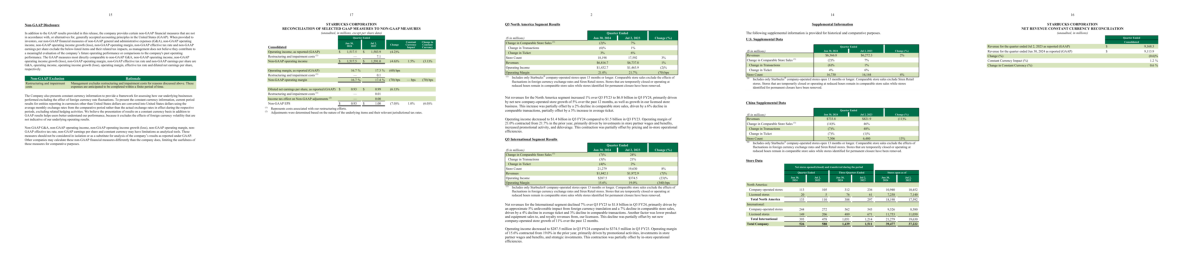

In [160]:
images = [ image_paths[i] for i in top_k_image_indices]
show_images(images)

In [156]:
encoded_images = encode_images_to_base64(images)

In [158]:
encoded_images

Output hidden; open in https://colab.research.google.com to view.

## Generative System

In [161]:
client = OpenAI(api_key = api_key)

In [162]:
# Define the System Prompt
# Define the system prompt
system_prompt = f"""
You are a financial advisor expert in publicly traded companies.
you must answer the {query}
You explain in clear terms with the data available only"""

In [164]:
image_messages = [
    {
        "type": "image_url",
        "image_url": {
            "url": f"data:image/jpg;base64,{img}",
            "detail": "high"
        }
    }
    for img in encoded_images
]

# Append the retrieved text as a separate text message
user_message_content = [
    {"type": "text", "text": "These are the images from the report pdf"},
    *image_messages,
    {"type": "text", "text": text_context}
]


In [166]:
response = client.chat.completions.create(
    model = "gpt-4o-mini",
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_message_content}
    ],
    temperature= 0.2
)

In [167]:
response

ChatCompletion(id='chatcmpl-Bjy6nP7pNubjUs4Okbr8eLXEneaUc', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Based on the provided data from the Starbucks report, here are the short-term risks for the company:\n\n1. **Declining Comparable Store Sales**: The North America segment reported a 2% decline in comparable store sales, while the International segment saw a 7% decline. This trend could indicate weakening customer demand or increased competition, which may impact revenue growth.\n\n2. **Increased Operating Costs**: Operating income decreased in both segments due to rising costs associated with wages, benefits, and promotional activities. This could pressure margins and profitability in the short term.\n\n3. **Foreign Currency Fluctuations**: The company is exposed to foreign currency risks, which can affect revenues and profitability, particularly in international markets. The report notes unfavorable impacts from currency trans

In [172]:
display(Markdown(response.choices[0].message.content))

Based on the provided data from the Starbucks report, here are the short-term risks for the company:

1. **Declining Comparable Store Sales**: The North America segment reported a 2% decline in comparable store sales, while the International segment saw a 7% decline. This trend could indicate weakening customer demand or increased competition, which may impact revenue growth.

2. **Increased Operating Costs**: Operating income decreased in both segments due to rising costs associated with wages, benefits, and promotional activities. This could pressure margins and profitability in the short term.

3. **Foreign Currency Fluctuations**: The company is exposed to foreign currency risks, which can affect revenues and profitability, particularly in international markets. The report notes unfavorable impacts from currency translation.

4. **Intensified Competition**: The coffee and beverage market is highly competitive, with significant price wars affecting profitability. This could lead to further erosion of market share if not managed effectively.

5. **Restructuring and Impairment Costs**: The company is incurring restructuring costs, which may impact short-term financial performance. While these costs are anticipated to be completed in a finite time, they still pose a risk to current earnings.

6. **Weakness in International Markets**: Specific regions, such as parts of Europe and the Middle East, are experiencing brand perception issues and declining sales. This could hinder overall growth and profitability in international operations.

7. **Operational Challenges**: The report mentions disruptions in the operating environment, which could affect store performance and customer experience. Any delays in operational improvements could further impact sales.

In summary, Starbucks faces several short-term risks, including declining sales, rising costs, currency fluctuations, competitive pressures, and operational challenges, all of which could affect its financial performance in the near term.